CNN

In [1]:
pip install tensorflow


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import glob
from sklearn.model_selection import train_test_split

In [3]:
X = []
Y = []

for i in glob.glob(r"C:\Users\jashw\OneDrive\Desktop\Sem 4\Robotics\Project\Preprocessed data\npz data\*\*.npz"):
    
    data = np.load(i)
    X.append(data["X"])
    Y.append(data["Y"])

X = np.array(X)
Y = np.array(Y)

In [4]:
print(len(X))
print(len(Y))

150
150


In [5]:
X = X[..., np.newaxis]

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=204)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=X_train.shape[1:]),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(15, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

c:\Users\jashw\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
history = model.fit(
    X_train,
    Y_train,
    epochs=25,
    batch_size=8,
    validation_data=(X_test,Y_test)
)

Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.0748 - loss: 33.5395 - val_accuracy: 0.7333 - val_loss: 1.5988
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 955ms/step - accuracy: 0.6242 - loss: 1.2530 - val_accuracy: 0.8667 - val_loss: 0.5349
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 984ms/step - accuracy: 0.9018 - loss: 0.2781 - val_accuracy: 1.0000 - val_loss: 0.0832
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 993ms/step - accuracy: 0.9269 - loss: 0.1549 - val_accuracy: 1.0000 - val_loss: 0.0497
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 1.0000 - loss: 0.0253 - val_accuracy: 1.0000 - val_loss: 9.2761e-04
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9739 - loss: 0.1281 - val_accuracy: 0.9667 - val_loss: 0.0469
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9797 - loss: 0.2461 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 1.0000 - loss: 0.0268 - val_accuracy: 1.00

In [10]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
train_loss, train_acc = model.evaluate(X_train, Y_train)

print("Test Accuracy : ", test_acc)
print("Test Loss : ", test_loss)
print()
print("Train Accuracy : ", train_acc)
print("Traain Loss : ", train_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step - accuracy: 1.0000 - loss: 5.6066e-06
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 1.0000 - loss: 1.9421e-05
Test Accuracy :  1.0
Test Loss :  5.606625109066954e-06

Train Accuracy :  1.0
Traain Loss :  2.3523269192082807e-05


ML

SVM

In [11]:
import os
import numpy as np

base = r"C:\Users\jashw\OneDrive\Desktop\Sem 4\Robotics\Project\Preprocessed data\npz data"

X = []
Y = []

for folder in sorted(os.listdir(base)):

    path = os.path.join(base, folder)

    for file in os.listdir(path):

        data = np.load(os.path.join(path, file))
        STF_data = data["X"]
        label = int(data["Y"])

        X.append(STF_data)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

In [12]:
print(len(X))
print(X.shape)
print()
print(len(Y))
print(Y.shape)

150
(150, 137, 1025)

150
(150,)


In [13]:
def STFT_FE(STF_data):

    thres = 1e-8

    mean_spec = np.mean(STF_data, axis=1)
    var_spec = np.var(STF_data, axis=1)

    freqs = np.arange(STF_data.shape[0])
    centroid = np.sum(freqs[:,None]*STF_data)/(np.sum(STF_data) + thres)
    bandwidth = np.sqrt(np.sum(((freqs[:,None] - centroid)**2)*STF_data)/(np.sum(STF_data) + thres))

    energy = np.sum(STF_data**2)

    return np.hstack([mean_spec[:40], var_spec[:40], centroid, bandwidth, energy])

In [14]:
X_feat = np.array([STFT_FE(i) for i in X])

print(X_feat.shape)

(150, 83)


In [15]:
X_train, Y_train, X_test, Y_test = [], [], [], []

for i in np.unique(Y):

    index = np.where(Y == i)[0]

    train_index = index[:8]
    test_index = index[8:]

    X_train.extend(X_feat[train_index])
    X_test.extend(X_feat[test_index])
    Y_train.extend(Y[train_index])
    Y_test.extend(Y[test_index])

X_train = np.array(X_train)
X_test = np.array(X_test)
Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma="scale", probability=True)
)

model.fit(X_train, Y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=10, probability=True))])

In [17]:
print("Train accuracy : ", model.score(X_train, Y_train))
print("Test accuracy : ", model.score(X_test, Y_test))

from sklearn.metrics import log_loss

probs1 = model.predict_proba(X_test)
loss1 = log_loss(Y_test, probs1)

print("Test Log Loss : ", loss1)

probs2 = model.predict_proba(X_train)
loss2 = log_loss(Y_train, probs2)

print("Train Log Loss : ", loss2)

Train accuracy :  1.0
Test accuracy :  0.8333333333333334
Test Log Loss :  1.0431747739636494
Train Log Loss :  0.8212174011798772


XGBoost

In [18]:
pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import os
import numpy as np

base = r"C:\Users\jashw\OneDrive\Desktop\Sem 4\Robotics\Project\Preprocessed data\npz data"

X = []
Y = []

for folder in sorted(os.listdir(base)):

    path = os.path.join(base, folder)

    for file in os.listdir(path):

        data = np.load(os.path.join(path, file))
        STF_data = data["X"]
        label = int(data["Y"])

        X.append(STF_data)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

In [20]:
print(len(X))
print(X.shape)
print()
print(len(Y))
print(Y.shape)

150
(150, 137, 1025)

150
(150,)


In [21]:
def STFT_FE(STF_data):

    thres = 1e-8

    mean_spec = np.mean(STF_data, axis=1)
    var_spec = np.var(STF_data, axis=1)

    freqs = np.arange(STF_data.shape[0])
    centroid = np.sum(freqs[:,None]*STF_data)/(np.sum(STF_data) + thres)
    bandwidth = np.sqrt(np.sum(((freqs[:,None] - centroid)**2)*STF_data)/(np.sum(STF_data) + thres))

    energy = np.sum(STF_data**2)

    return np.hstack([mean_spec[:40], var_spec[:40], centroid, bandwidth, energy])

In [22]:
X_feat = np.array([STFT_FE(i) for i in X])

print(X_feat.shape)

(150, 83)


In [23]:
X_train, Y_train, X_test, Y_test = [], [], [], []

for i in np.unique(Y):

    index = np.where(Y == i)[0]

    train_index = index[:8]
    test_index = index[8:]

    X_train.extend(X_feat[train_index])
    X_test.extend(X_feat[test_index])
    Y_train.extend(Y[train_index])
    Y_test.extend(Y[test_index])

X_train = np.array(X_train)
X_test = np.array(X_test)
Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=15,
    eval_metric="mlogloss",
    random_state=204
)

xgb.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=15, num_parallel_tree=None, ...)

In [25]:
print("Train accuracy : ", xgb.score(X_train, Y_train))
print("Test accuracy : ", xgb.score(X_test, Y_test))

from sklearn.metrics import log_loss

probs_test = xgb.predict_proba(X_test)
probs_train = xgb.predict_proba(X_train)

print("Test log-loss : ", log_loss(Y_test, probs_test))
print("Train log-loss : ", log_loss(Y_train, probs_train))

Train accuracy :  1.0
Test accuracy :  0.9
Test log-loss :  0.3938596788732419
Train log-loss :  0.07400944593115269


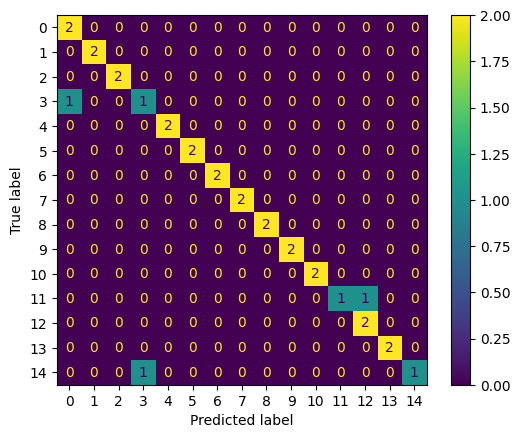

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Y_pred = xgb.predict(X_test)
Conf_Mat = confusion_matrix(Y_test, Y_pred)

ConfusionMatrixDisplay(Conf_Mat).plot()
plt.show()

In [27]:
xgb.save_model("Audio_Files_XGBoost_Trained.json")

In [28]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.load_model("Audio_Files_XGBoost_Trained.json")

## Testing

In [32]:
from Final_Preprocessing import Preprocessing

In [29]:
class_names = np.array([
    "AISI 304 steel",
    "AISI 316 steel",
    "Aluminium 6082",
    "B10 bronze",
    "B12 bronze",
    "BrAl alloy",
    "C45E steel",
    "Copper",
    "CW614 brass",
    "Fe37 drawn",
    "HDPE",
    "Nylon 6",
    "Pom-C",
    "Teflon",
    "X150 steel"  
])

In [ ]:
import librosa
import numpy as np

# audio, sr = librosa.load("", sr=48000)

PreProcess = Preprocessing(frame_length=2048, hop_length=512, fixed_sample_rate=48000)

audio = glob.glob(r"C:\Users\jashw\OneDrive\Desktop\Sem 4\Robotics\Project\Dataset\Audio data\AISI 304 steel\AISI 304 steel (1).mp3")

raw, trimmed, start, end = PreProcess.trim_pad_standardize(audio)

normalized = PreProcess.rms_normalization(trimmed)

filtered = PreProcess.bandpass(normalized)

emphasized = PreProcess.pre_emphasis(filtered)

audio_stft = PreProcess.STFT_fast(emphasized[0])

# audio_stft = []

# for signal in emphasized:
#     temp = PreProcess.STFT_fast(signal)
#     audio_stft.append(temp)

# audio_stft = np.array(audio_stft)

FE_data = STFT_FE(audio_stft)

FE_data = FE_data.reshape(1,-1)

pred = xgb.predict(FE_data)[0]
probs = xgb.predict_proba(FE_data)[0]

print("Predicted Class index : ", pred)
print("Confidence : ", np.max(probs))

if np.max(probs) < 0.6:
    print("A metal sound")
else:
    print("Detected Class : ", class_names[pred])

Predicted Class index :  0
Confidence :  0.94521123
Detected Class :  AISI 304 steel
